In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [4]:
project_path = "/content/drive/MyDrive/Network_Intrusion_Detection_Project/data/"
model_path = "/content/drive/MyDrive/Network_Intrusion_Detection_Project/models/"

os.makedirs(model_path, exist_ok=True)

In [5]:
X_train = pd.read_csv(project_path + "X_train_processed.csv")
X_test = pd.read_csv(project_path + "X_test_processed.csv")

y_train = pd.read_csv(project_path + "y_train.csv").values.ravel()
y_test = pd.read_csv(project_path + "y_test.csv").values.ravel()

print("Train shape:", X_train.shape)

Train shape: (90664, 43)


In [6]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='sigmoid'))  # Binary classification

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,001 (62.50 KB)

 Trainable params: 16,001 (62.50 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9297 - loss: 0.1683 - val_accuracy: 0.9963 - val_loss: 0.0290
Epoch 2/20
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9977 - loss: 0.0103 - val_accuracy: 0.9997 - val_loss: 0.0119
Epoch 3/20
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9989 - loss: 0.0036 - val_accuracy: 0.9998 - val_loss: 0.0119
Epoch 4/20
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9995 - loss: 0.0017 - val_accuracy: 0.9998 - val_loss: 0.0226
Epoch 5/20
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9994 - loss: 0.0023 - val_accuracy: 0.9998 - val_loss: 0.0220
Epoch 6/20
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9998 - loss: 8.4000e-04 - val_accuracy: 0.9998 - val_loss: 0.0234


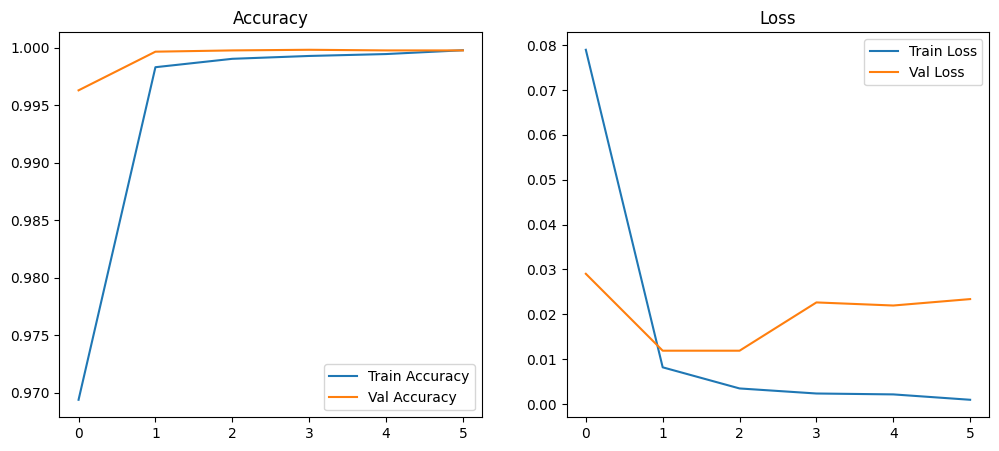

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [9]:
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

print("DL Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

5480/5480 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
DL Accuracy: 0.878613672786171

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.62      0.77     56000
           1       0.85      1.00      0.92    119341

    accuracy                           0.88    175341
   macro avg       0.92      0.81      0.84    175341
weighted avg       0.90      0.88      0.87    175341



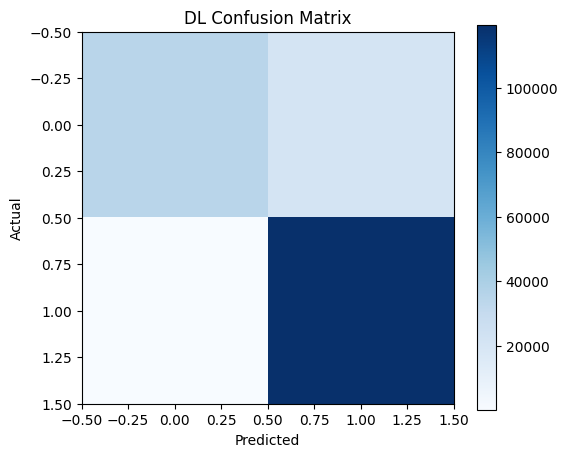

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("DL Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
model.save(model_path + "dl_intrusion_model.h5")

print("Deep Learning model saved successfully ✅")

Deep Learning model saved successfully ✅


NameError: name 'new_data_scaled' is not defined